PyTorch 학습을 위한 3문제:
1. Tensor 생성 및 기본 연산
    3x3 크기의 랜덤 텐서를 생성하고, 각 요소에 10을 더한 후 출력하세요.
    동일한 크기의 영행렬을 생성하고, 두 행렬을 element-wise 덧셈한 결과를 출력하세요.


2. Autograd를 활용한 미분 계산

    y = 3x^2 + 2x + 1 라는 함수가 주어졌을 때,
    𝑥
    =
    2
    에서의 미분값을 PyTorch로 계산하세요.


3. MNIST 데이터셋 활용

    PyTorch의 torchvision을 이용하여 MNIST 데이터셋을 로드하고, 첫 번째 이미지를 출력하세요.

In [2]:
# 한글 폰트
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [4]:
import platform
#Colab, Linux
#나눔고딕폰트의 경로명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()
font_name

'NanumGothic'

In [5]:
# dir(plt.rcParams)

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name
# 기본 폰트사이즈
plt.rcParams['font.size'] = 14
# 기본 그래프 사이즈
plt.rcParams['figure.figsize'] = (4,4)
# 기본 그리드 표시
#필요에 따라 설정 시  plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
# 마이너스 기호 정상출력
plt.rcParams['axes.unicode_minus'] = False
#넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [6]:
# 1. Tensor 생성 및 기본 연산 3x3 크기의 랜덤 텐서를 생성하고, 각 요소에 10을 더한 후 출력하세요.
# 동일한 크기의 영행렬을 생성하고, 두 행렬을 element-wise 덧셈한 결과를 출력하세요.

import torch

tensor1 = torch.rand(3, 3)
result = tensor1 + 10
print("random Tensor : \n", tensor1)
print("add 10 : \n", result)

print('\n')

tensor2 = torch.zeros(3, 3)
print('3x3 영행렬 : \n', tensor2)

sum_result = tensor1 + tensor2
print("행렬 덧셈 : \n", sum_result)


random Tensor : 
 tensor([[0.7639, 0.3252, 0.4287],
        [0.1781, 0.8402, 0.9896],
        [0.4535, 0.5010, 0.2131]])
add 10 : 
 tensor([[10.7639, 10.3252, 10.4287],
        [10.1781, 10.8402, 10.9896],
        [10.4535, 10.5010, 10.2131]])


3x3 영행렬 : 
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
행렬 덧셈 : 
 tensor([[0.7639, 0.3252, 0.4287],
        [0.1781, 0.8402, 0.9896],
        [0.4535, 0.5010, 0.2131]])


In [18]:
# 2. Autograd를 활용한 미분 계산
# y = 3x^2 + 2x + 1 라는 함수가 주어졌을 때, 𝑥 = 2 에서의 미분값을 PyTorch로 계산하세요.

import torch

x = torch.tensor(2.0, requires_grad=True)

# 함수 정의: y = 3x^2 + 2x + 1
y = 3 * x ** 2 + 2 * x + 1

# backpropagation
y.backward()

# 미분값
print("dy/dx at x=2:", x.grad.item)


dy/dx at x=2: <built-in method item of Tensor object at 0x7a0ab8682870>


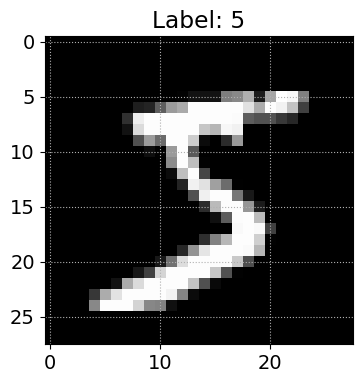

In [ ]:
# 3. MNIST 데이터셋 활용
# PyTorch의 torchvision을 이용하여 MNIST 데이터셋을 로드하고, 첫 번째 이미지를 출력하세요

## gpt 활용 


import torchvision.transforms as transforms  # 이미지 데이터를 변환하기 위한 torchvision의 transforms 모듈 import
import torchvision.datasets as datasets  # PyTorch에서 제공하는 데이터셋을 불러오기 위해 import
import matplotlib.pyplot as plt  # 이미지를 출력하기 위한 matplotlib 라이브러리 import

# MNIST 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor()])
# transforms.ToTensor(): 이미지를 PyTorch 텐서로 변환 (0~255 범위를 0~1로 정규화)
# transforms.Compose(): 여러 개의 변환을 순서대로 적용할 수 있도록 묶어줌

mnist_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
# MNIST 데이터셋을 다운로드하고, 변환(transform)하여 저장 (훈련 데이터 사용)
# root="./data": 데이터를 저장할 경로 지정
# train=True: 훈련용 데이터셋을 불러옴 (False일 경우 테스트 데이터셋)
# download=True: MNIST 데이터가 없으면 다운로드함

# 첫 번째 이미지 가져오기
image, label = mnist_dataset[0]   ## MNIST 데이터셋에서 첫 번째 샘플(이미지, 라벨) 가져오기

# 이미지 출력
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()


(70000, 784)


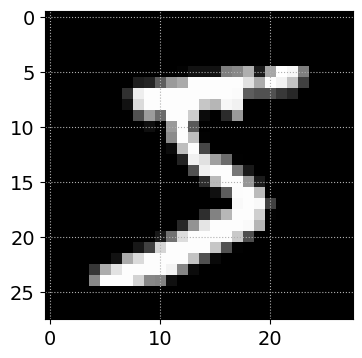

In [23]:
# 3. MNIST 데이터셋 활용
# PyTorch의 torchvision을 이용하여 MNIST 데이터셋을 로드하고, 첫 번째 이미지를 출력하세요

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version = 1, as_frame = False)

image = mnist.data
print(image.shape)

sample = image[0].reshape(28,28)
plt.imshow(sample, cmap='gray')
plt.show()